# Atividade de vendas no Brasil

In [5]:
import pandas as pd 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Carregando dataset
df = pd.read_csv('../../data/vendas_brasil_1.csv')

# Mostra as primeiras linhas
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregável 1 NumPy

### A. Criando arrays

In [ ]:
# Convertendo colunas do DataFrame Pandas para arrays NumPy.
preco_unitario = df['preco_unitario'].values
custo_unitario = df['custo_unitario'].values
quantidade = df['quantidade'].values
desconto_pct = df['desconto_pct'].values
frete = df['frete'].values

### B. Cálculos com operações vetorizadas

In [10]:
# 1. Valor bruto da venda
valor_bruto = preco_unitario * quantidade

# 2. Valor do desconto
valor_desconto = valor_bruto * (desconto_pct / 100)

# Variável auxiliar de Receita Total para os próximos cálculos 
receita_total = valor_bruto - valor_desconto

# 3. Custo total
custo_total = (custo_unitario * quantidade) + frete

# 4. Lucro estimado
lucro_estimado = receita_total - custo_total

### C. Máscaras booleanas

In [11]:
# 1. Vendas com receita acima da média 
mascara_receita_alta = receita_total > np.mean(receita_total)

# 2. Vendas com prejuízo
mascara_prejuizo = lucro_estimado < 0

# 3. Vendas com desconto alto (considerando maior que 20% como regra de negócio arbitrária) [cite: 28]
mascara_desconto_alto = desconto_pct > 0.20

# Usando as máscaras para contar os casos encontrados [cite: 29]
print(f"Qtd vendas com receita acima da média: {np.sum(mascara_receita_alta)}")
print(f"Qtd vendas com prejuízo: {np.sum(mascara_prejuizo)}")
print(f"Qtd vendas com desconto alto: {np.sum(mascara_desconto_alto)}")

Qtd vendas com receita acima da média: 9207
Qtd vendas com prejuízo: 7451
Qtd vendas com desconto alto: 28912


### D. Agregações

In [16]:
# Calculando as agregações solicitadas

# 1. Receita média
receita_media = np.nanmean(receita_total)

# 2. Maior receita
maior_receita = np.nanmax(receita_total)

# 3. Menor receita
menor_receita = np.nanmin(receita_total)

# 4. Lucro médio (Corrigido para ignorar os valores nulos)
lucro_medio = np.nanmean(lucro_estimado)

# 5. Quantidade de vendas com prejuízo
qtd_prejuizo = np.sum(mascara_prejuizo)

# Exibindo os resultados formatados na moeda local (Reais)
print(f"Receita Média: R$ {receita_media:,.2f}")
print(f"Maior Receita: R$ {maior_receita:,.2f}")
print(f"Menor Receita: R$ {menor_receita:,.2f}")
print(f"Lucro Médio: R$ {lucro_medio:,.2f}")
print(f"Quantidade de vendas com prejuízo: {qtd_prejuizo}")

Receita Média: R$ 1,720.53
Maior Receita: R$ 51,376.47
Menor Receita: R$ 3.71
Lucro Médio: R$ 311.86
Quantidade de vendas com prejuízo: 7451


### Conclusão sobre o comportamento geral das vendas

A análise vetorizada com NumPy revelou dados muito interessantes sobre a saúde financeira e a política de preços da operação. 

O negócio possui uma **alta disparidade no ticket**, com receitas que variam de apenas R$ 3,71 a valores bem expressivos de mais de R$ 51.000,00, fechando em uma receita média sólida de R$ 1.720,53 por venda. Além disso, identificamos que mais de 9.200 vendas superaram essa média, indicando a presença de transações de alto valor.

No entanto, o ponto de maior atenção para a rentabilidade da empresa está na política promocional. Descobrimos um volume altíssimo de transações com **descontos agressivos** (28.912 vendas com mais de 20% de desconto). Essa estratégia de forte abatimento de preço está diretamente correlacionada às **7.451 vendas que operaram no vermelho (com prejuízo)**. 

Em resumo, embora a empresa consiga gerar transações de alta receita, a agressividade nos descontos está corroendo a margem de milhares de pedidos, o que sugere a necessidade de uma revisão nas regras de precificação e frete para proteger o lucro da operação no Brasil.

## Entregável 2 Pandas
Neste entregável, o foco é usar Pandas para ler, explorar, limpar, transformar e agrupar os dados.

### A. Primeiro olhar no dataset
Exploração inicial para entender o formato e a integridade dos dados.

In [19]:
# Exploração básica das informações
display(df.head())
print("\n--- INFORMAÇÕES DO DATASET ---")
df.info()

print("\n--- ESTATÍSTICAS DESCRITIVAS ---")
display(df.describe())

print(f"\nO dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

print("\n--- VALORES FALTANTES (NaN) ---")
print(df.isna().sum())

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False



--- INFORMAÇÕES DO DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-nu

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000



O dataset possui 37617 linhas e 21 colunas.

--- VALORES FALTANTES (NaN) ---
data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64


**Respostas da exploração inicial:**
1. **Quantas linhas e colunas existem?** O dataset possui 37.617 linhas e 21 colunas.
2. **Existem dados faltantes?** Sim. Existem valores nulos nas colunas: `canal_venda` (50), `vendedor` (40), `margem_pct` (82), `frete` (1879), `avaliacao_cliente` (2955) e `prazo_entrega_dias` (1504).
3. **Quais colunas parecem numéricas?** As colunas do tipo int64 e float64: `mes`, `quantidade`, `preco_unitario`, `custo_unitario`, `margem_pct`, `desconto_pct`, `receita_total`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias`.
4. **Quais colunas parecem categóricas?** As de texto (str) e booleanas (bool): `data_venda` (que trataremos como data), `cidade`, `canal_venda`, `categoria`, `produto`, `vendedor`, `fidelidade_cliente`, `devolucao`, `entrega_no_prazo`, `alta_temporada` e `flag_outlier_preco`.

### B. Limpeza e tratamento
Realizando os ajustes necessários para garantir a qualidade da análise.

In [ ]:
# 1. Convertendo a coluna de data para o tipo datetime
df['data_venda'] = pd.to_datetime(df['data_venda'], dayfirst=True, format='mixed')

# 2. Padronizando a coluna 'categoria'
df['categoria'] = df['categoria'].str.strip().str.title()

# 3. Tratamento de dados faltantes (focando nos reais problemas do dataset)
# Preenchendo avaliações e prazos de entrega vazios com a mediana para não sofrer distorção de outliers
mediana_avaliacao = df['avaliacao_cliente'].median()
df['avaliacao_cliente'] = df['avaliacao_cliente'].fillna(mediana_avaliacao)

mediana_prazo = df['prazo_entrega_dias'].median()
df['prazo_entrega_dias'] = df['prazo_entrega_dias'].fillna(mediana_prazo)

# Preenchendo textos vazios (canal de venda e vendedor) com "Não Informado"
df['canal_venda'] = df['canal_venda'].fillna('Não Informado')
df['vendedor'] = df['vendedor'].fillna('Não Informado')

# Para o frete faltante, assumiremos o valor 0 (como se fosse frete grátis nessas ocorrências)
df['frete'] = df['frete'].fillna(0)

**Decisões tomadas na limpeza:**
A coluna `data_venda` foi convertida para o tipo `datetime`. Padronizamos a coluna `categoria` usando `.str.title()` e removendo espaços em branco extras, garantindo uniformidade no agrupamento. 

Para os dados faltantes, adotamos diferentes estratégias: variáveis numéricas com dispersão (`avaliacao_cliente` e `prazo_entrega_dias`) foram preenchidas com a mediana para evitar que notas ou prazos extremos distorçam o padrão. Valores categóricos ausentes (`canal_venda` e `vendedor`) foram classificados como "Não Informado". Por fim, os `fretes` não registrados foram preenchidos com 0, assumindo a premissa de frete grátis ou subsidiado para essas transações específicas.

### C. Criação de novas colunas
Criação de variáveis auxiliares, incluindo a aplicação de uma função `lambda`.

In [ ]:
# 1. Ano da venda
df['ano_venda'] = df['data_venda'].dt.year

# 2. Mês da venda
df['mes_venda'] = df['data_venda'].dt.month

# 3. Faixa de receita (utilizando apply e lambda)
# Classifica a venda como Alta, Média ou Baixa de acordo com o valor financeiro
df['faixa_receita'] = df['receita_total'].apply(
    lambda x: 'Alta (> R$ 2000)' if x > 2000 else ('Média (> R$ 500)' if x > 500 else 'Baixa')
)

### D. Filtros
Extraindo respostas rápidas sobre a operação usando máscaras do Pandas.

In [24]:
# 1. Quais vendas tiveram receita acima de R$ 5.000,00?
vendas_premium = df[df['receita_total'] > 5000]
print(f"Qtd de vendas premium (acima de R$ 5.000,00): {len(vendas_premium)}")

# 2. Quais vendas tiveram devolução?
vendas_devolvidas = df[df['devolucao'] == True]
print(f"Qtd total de pedidos devolvidos: {len(vendas_devolvidas)}")

# 3. Quais vendas pertencem à categoria de Eletrônicos?
vendas_eletronicos = df[df['categoria'] == 'Eletrônicos']
print(f"Qtd de vendas na categoria Eletrônicos: {len(vendas_eletronicos)}")

Qtd de vendas premium (acima de R$ 5.000,00): 4004
Qtd total de pedidos devolvidos: 3532
Qtd de vendas na categoria Eletrônicos: 7515


**Explicação dos filtros:**
Os filtros mostraram os volumes exatos para situações chave: conseguimos isolar rapidamente as vendas premium de alto ticket, o total de produtos da categoria 'Eletrônicos' e, o mais importante para a logística, quantificar exatamente os pedidos que geraram logística devolução.

### E. Agrupamentos com groupby
Análise agregada para responder perguntas de negócio.

In [25]:
# 1. Qual categoria teve maior receita total?
receita_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
print("--- RECEITA TOTAL POR CATEGORIA ---")
for cat, val in receita_categoria.items():
    print(f"{cat}: R$ {val:,.2f}")

# 2. Qual canal de venda teve maior quantidade de vendas (volume de itens)?
qtd_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
print("\n--- QUANTIDADE DE ITENS VENDIDOS POR CANAL ---")
print(qtd_canal)

# 3. Qual cidade teve maior receita?
receita_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
print("\n--- RECEITA TOTAL POR CIDADE ---")
for cid, val in receita_cidade.items():
    print(f"{cid}: R$ {val:,.2f}")

--- RECEITA TOTAL POR CATEGORIA ---
Eletrônicos: R$ 45,017,479.88
Esportes: R$ 11,567,480.75
Vestuário: R$ 6,780,473.93
Livros: R$ 4,462,597.93
Alimentação: R$ 3,331,601.51

--- QUANTIDADE DE ITENS VENDIDOS POR CANAL ---
canal_venda
Site Web         84503
App Mobile       83188
Loja Física      56318
Marketplace      41707
Televendas       13726
Não Informado      373
app mobile         240
SiteWeb            231
APP Mobile         221
Site web           203
App mobile         190
loja física        180
site web           154
Loja Fisica        109
Loja fisica         98
Name: quantidade, dtype: int64

--- RECEITA TOTAL POR CIDADE ---
Recife: R$ 7,638,412.70
Manaus: R$ 7,435,641.08
Fortaleza: R$ 7,224,144.20
Goiânia: R$ 7,137,063.48
Porto Alegre: R$ 7,026,847.56
Curitiba: R$ 6,908,794.29
Salvador: R$ 6,850,939.15
Belo Horizonte: R$ 6,843,262.46
Rio de Janeiro: R$ 6,813,063.15
São Paulo: R$ 6,771,119.98
salvador: R$ 37,694.31
Goiânia : R$ 35,476.13
Curtiba: R$ 31,004.77
SP: R$ 27,222.85

**Respostas dos agrupamentos:**

1. **Qual categoria teve maior receita total?** A categoria com maior receita foi **Eletrônicos**, gerando um faturamento expressivo de R$ 45.017.479,88, o que representa uma larga vantagem sobre a segunda colocada (Esportes, com pouco mais de R$ 11,5 milhões).

2. **Qual canal de venda teve maior quantidade de vendas?** O **Site Web** liderou o volume com 84.503 itens vendidos, seguido de perto pelo App Mobile (83.188 itens). 

3. **Qual cidade teve maior receita?** A cidade de **Recife** liderou o ranking com R$ 7.638.412,70 em receita total, seguida por Manaus (R$ 7.435.641,08) e Fortaleza (R$ 7.224.144,20).

### F. Merge
Relacionando o dataset a uma tabela auxiliar de regiões geográficas do Brasil.

In [26]:
# Criando uma tabela auxiliar manualmente com algumas cidades
dados_regioes = {
    'cidade': ['Rio de Janeiro', 'Manaus', 'Goiânia', 'Fortaleza', 'Belo Horizonte', 'São Paulo', 'Curitiba'],
    'regiao': ['Sudeste', 'Norte', 'Centro-Oeste', 'Nordeste', 'Sudeste', 'Sudeste', 'Sul']
}
df_regioes = pd.DataFrame(dados_regioes)

# Fazendo o merge (left join) com o dataset principal
df_completo = df.merge(df_regioes, on='cidade', how='left')

# Análise simples pós-merge: Receita total por região brasileira
receita_regiao = df_completo.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)

print("--- RECEITA TOTAL POR REGIÃO (Pós-Merge) ---")
for reg, val in receita_regiao.items():
    print(f"{reg}: R$ {val:,.2f}")

--- RECEITA TOTAL POR REGIÃO (Pós-Merge) ---
Sudeste: R$ 20,427,445.59
Norte: R$ 7,435,641.08
Nordeste: R$ 7,224,144.20
Centro-Oeste: R$ 7,137,063.48
Sul: R$ 6,908,794.29


### Conclusão do Entregável 2

Nesta etapa, utilizamos o Pandas para transformar dados brutos em informações analíticas confiáveis. Realizamos tratamentos estratégicos de valores nulos (utilizando medianas e preenchimentos lógicos) e criamos novas colunas que enriqueceram a análise.

Os agrupamentos revelaram insights de negócio claros: **Eletrônicos** e o **Site Web** são os motores de receita e volume, respectivamente, com **Recife** liderando o faturamento por cidade. Além disso, a exploração evidenciou a presença de ruídos de digitação e falta de padronização nas strings (como variações de nomes de cidades e canais).

Por fim, o **merge** geográfico destacou a liderança absoluta do **Sudeste** (faturando R$ 20,4 milhões), enquanto as demais regiões mantêm um forte equilíbrio comercial, oscilando entre R$ 6,9 milhões e R$ 7,4 milhões.

## Entregável 3 Seaborn

Neste entregável, o foco é criar visualizações com a biblioteca Seaborn e interpretar os resultados. Serão aplicadas personalizações visuais para garantir que os gráficos fiquem claros, profissionais e fáceis de ler.

### A. Gráfico de barras
Comparação da receita total gerada por cada categoria de produtos.

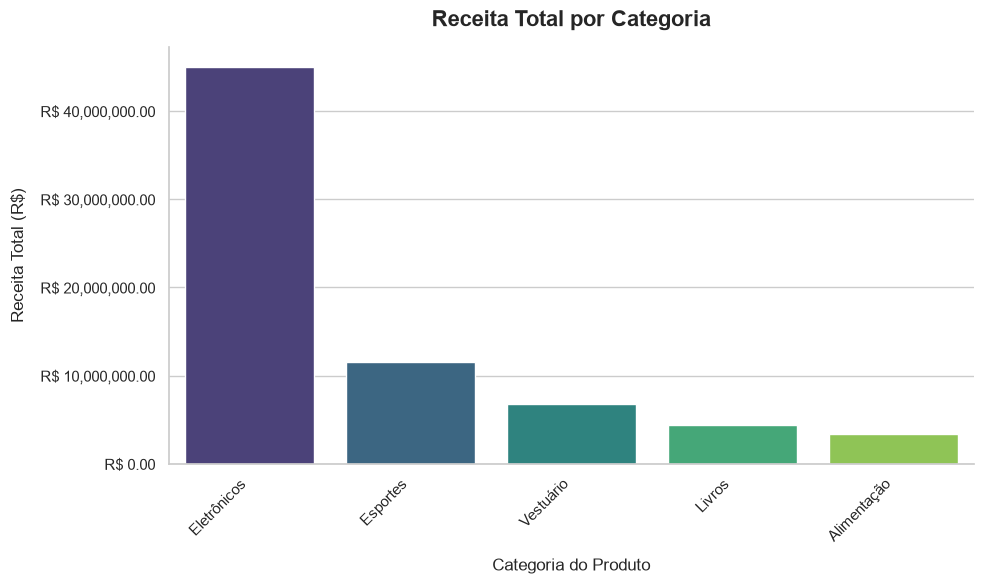

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Preparando os dados: Receita total por categoria ordenada de forma decrescente
df_barras = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False).reset_index()

# 2. Configurando o estilo geral e o tamanho da figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de barras
ax = sns.barplot(
    data=df_barras, 
    x='categoria', 
    y='receita_total', 
    hue='categoria',
    palette='viridis',
    legend=False
)

# 4. Títulos e rótulos
plt.title('Receita Total por Categoria', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Categoria do Produto', fontsize=12, labelpad=10)
plt.ylabel('Receita Total (R$)', fontsize=12, labelpad=10)

# Rotacionando os rótulos do eixo X 
plt.xticks(rotation=45, ha='right')

# 5. Formatando o eixo Y para exibir valores em Reais (BRL)
def formatar_moeda(x, pos):
    # Formata com separador de milhar e duas casas decimais
    return f'R$ {x:,.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(formatar_moeda))

# 6. Removendo as bordas superior e direita para ter um visual mais moderno
sns.despine()

# Ajustando o layout e exibindo o gráfico
plt.tight_layout()
plt.show()

**Interpretação do Gráfico de Barras:**
O gráfico evidencia de forma clara a dependência do faturamento em relação à categoria de **Eletrônicos**. Com uma receita superior a R$ 45 milhões, ela representa a esmagadora maioria do faturamento da empresa, sendo quase quatro vezes maior que a segunda colocada (Esportes). Categorias como Vestuário, Livros e Alimentação possuem uma participação financeira muito menor, sugerindo que o core business atual está concentrado em produtos de alto ticket tecnológico.

### B. Gráfico de linha
Visualização da evolução da receita total ao longo dos meses para identificar sazonalidades ou tendências de venda.

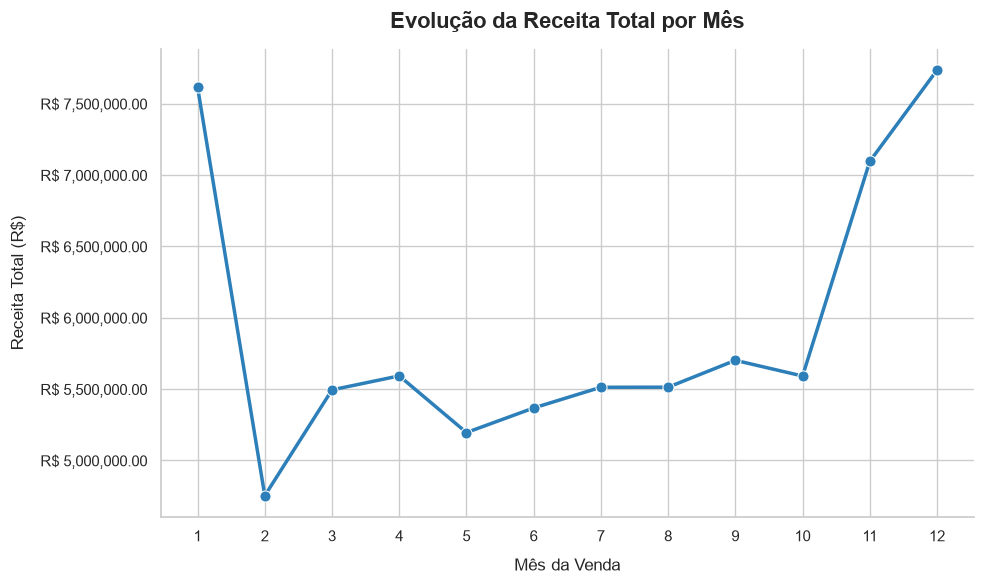

In [ ]:
# 1. Preparando os dados: Agrupando a receita total pelo mês
df_linha = df.groupby('mes')['receita_total'].sum().reset_index()

# 2. Configurando o estilo e tamanho da figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de linha com marcadores e ajuste de espessura (linewidth)
ax = sns.lineplot(
    data=df_linha,
    x='mes',
    y='receita_total',
    marker='o',       # Destaca cada ponto mensal
    markersize=8,
    linewidth=2.5,    # Linha mais espessa conforme exigido na atividade
    color='#2c7fb8'
)

# 4. Títulos e Eixos
plt.title('Evolução da Receita Total por Mês', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mês da Venda', fontsize=12, labelpad=10)
plt.ylabel('Receita Total (R$)', fontsize=12, labelpad=10)

# Garantindo que o eixo X mostre os meses inteiros (1 a 12) sem quebrar os números
plt.xticks(range(1, 13))

# 5. Formatando o eixo Y para exibir valores em Reais (BRL)
def formatar_moeda_linha(x, pos):
    return f'R$ {x:,.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(formatar_moeda_linha))

# 6. Acabamento visual
sns.despine()

# Ajustando layout e exibindo
plt.tight_layout()
plt.show()

**Interpretação do Gráfico de Linha:**
A evolução mensal revela uma forte sazonalidade no faturamento da empresa. O ano começa com uma receita altíssima em janeiro (acima de R$ 7,5 milhões), sofrendo uma queda drástica em fevereiro, que representa o pior mês de vendas (abaixo de R$ 5 milhões). Do mês 3 ao 10, o faturamento se mantém estável, sem grandes picos. O cenário muda radicalmente a partir de novembro, com uma escalada vertiginosa que culmina no pico máximo em dezembro (próximo a R$ 7,7 milhões), comportamento clássico impulsionado por datas comemorativas de fim de ano e Black Friday.

### C. Gráfico de dispersão
Análise da relação entre duas variáveis numéricas. Para evitar poluição visual, utilizaremos uma amostra dos dados. Vamos analisar se existe correlação entre o percentual de desconto aplicado e a receita total gerada pela venda.

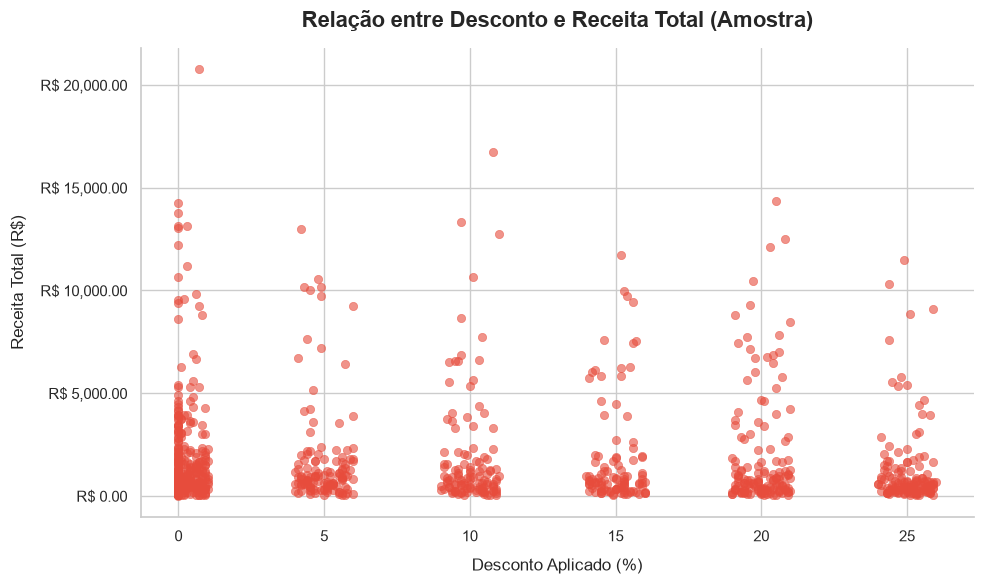

In [ ]:
# 1. Preparando os dados: Pegando uma amostra aleatória de 1000 registros
df_amostra = df.sample(n=1000, random_state=42)

# 2. Configurando o estilo e tamanho da figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de dispersão (scatterplot)
# Usamos 'alpha' para deixar os pontos semi-transparentes e facilitar a visualização de sobreposições
ax = sns.scatterplot(
    data=df_amostra, 
    x='desconto_pct', 
    y='receita_total', 
    color='#e74c3c', 
    alpha=0.6,
    edgecolor=None
)

# 4. Títulos e Eixos
plt.title('Relação entre Desconto e Receita Total (Amostra)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Desconto Aplicado (%)', fontsize=12, labelpad=10)
plt.ylabel('Receita Total (R$)', fontsize=12, labelpad=10)

# 5. Formatando o eixo Y para exibir valores em Reais (BRL)
def formatar_moeda_dispersao(x, pos):
    return f'R$ {x:,.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(formatar_moeda_dispersao))

# 6. Acabamento visual
sns.despine()

# Ajustando layout e exibindo
plt.tight_layout()
plt.show()

**Interpretação do Gráfico de Dispersão:**
A amostra revela dois comportamentos curiosos na política de preços da empresa. Primeiro, notamos que os descontos não são aplicados de forma contínua, mas sim em "degraus" fixos (0%, 5%, 10%, 15%, 20% e 25%), formando essas colunas verticais bem definidas. Segundo, e mais importante para a estratégia comercial: as vendas de altíssimo ticket (acima de R$ 15.000,00) ocorrem quase exclusivamente na faixa de 0% de desconto. Conforme o percentual de desconto aumenta, o "teto" de receita gerada por venda cai drasticamente, indicando que produtos premium dificilmente entram em grandes promoções.

### D. Mapa de calor
Criação de um heatmap para identificar a correlação (positiva ou negativa) entre as variáveis numéricas do nosso dataset.

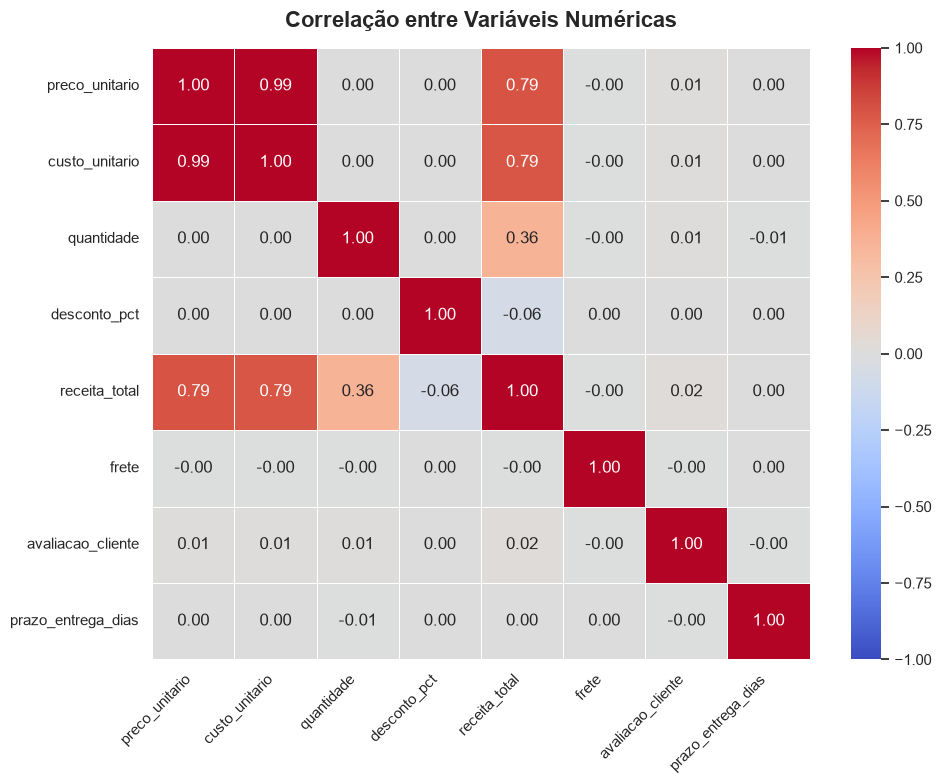

In [34]:
# 1. Selecionando apenas as colunas numéricas pertinentes para evitar erros no cálculo
colunas_numericas = [
    'preco_unitario', 'custo_unitario', 'quantidade', 
    'desconto_pct', 'receita_total', 'frete', 
    'avaliacao_cliente', 'prazo_entrega_dias'
]

# Calculando a matriz de correlação de Pearson
df_corr = df[colunas_numericas].corr()

# 2. Configurando o tamanho da figura
plt.figure(figsize=(10, 8))

# 3. Criando o heatmap
ax = sns.heatmap(
    df_corr,
    annot=True,          # Habilita os números dentro dos quadrados
    fmt='.2f',           # Formata para 2 casas decimais
    cmap='coolwarm',     # Paleta clássica: azul (correlação negativa) para vermelho (positiva)
    linewidths=0.5,      # Adiciona uma linha fina separando os quadrados (acabamento visual)
    vmin=-1, vmax=1      # Fixa a escala térmica de -1 a 1
)

# 4. Melhorando a apresentação
plt.title('Correlação entre Variáveis Numéricas', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')

# Ajustando o layout e exibindo
plt.tight_layout()
plt.show()

**Interpretação do Mapa de Calor:**
O heatmap revela de forma clara quais alavancas movem o negócio. Existe uma correlação quase perfeita (0.99) entre o `preco_unitario` e o `custo_unitario`, indicando margens muito bem fixadas. Além disso, a `receita_total` é fortemente impulsionada pelo ticket do produto (0.79) e apenas moderadamente pelo volume de itens (`quantidade`, com 0.36). 

Um insight contra-intuitivo e muito importante revelado pelo gráfico é a ausência de correlação (0.00) entre variáveis operacionais. Neste dataset, o `prazo_entrega_dias` e o valor do `frete` não demonstram impacto linear na `avaliacao_cliente`, e os descontos (`desconto_pct`) têm uma relação negativa quase nula (-0.06) com a receita gerada.

### Conclusão Final do Projeto

Ao longo deste notebook, a integração de **NumPy**, **Pandas** e **Seaborn** nos permitiu transformar um arquivo bruto em inteligência de negócio. 

Identificamos que o core da operação reside na venda de produtos de alto ticket da categoria de **Eletrônicos** pelo **Site Web**, com um mercado dominante na região **Sudeste**. As análises visuais e estatísticas demonstraram que o faturamento da empresa possui uma forte sazonalidade no fim do ano e depende majoritariamente do preço dos produtos, e não apenas do volume de vendas. Além disso, as variáveis logísticas (como frete e prazo) não estão afetando diretamente a nota dada pelos clientes.

Com a base de dados devidamente limpa, tratada e com seus comportamentos mapeados, os dados encontram-se estruturados e prontos para serem exportados para o PostgreSQL, garantindo que as futuras consultas e integrações da empresa sejam sempre guiadas por informações sólidas e confiáveis.